### Loading the dataset

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train,y_train),(X_test,y_test) = fashion_mnist.load_data()

In [2]:
print(X_train.shape)
print(X_test.shape)


(60000, 28, 28)
(10000, 28, 28)


In [3]:
print(y_train[0].shape)
print(y_train.shape)
print(y_train)

()
(60000,)
[9 0 0 ... 3 0 5]


### Normalizing the Dataset

In [4]:
X_train = X_train/255.0
X_test = X_test/255.0

### Converting the input 2D images to 1D vector

In [5]:
print(X_train[0].shape)
X_train = X_train.reshape(-1,784)
X_test = X_test.reshape(-1,784) 
print(X_train[0].shape)

(28, 28)
(784,)


### Encoding the output

In [6]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

print(y_train[0].shape)
print(y_train.shape)
print(y_train)

(10,)
(60000, 10)
[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Building the Neural Network Model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

model = Sequential()

model.add(Dense(256,activation='relu',input_shape=(784,)))
model.add(Dropout(0.3))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(10,activation='softmax'))

c:\Users\jayso\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


### Training the Model

In [10]:
history = model.fit(X_train,y_train,epochs=10,batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7407 - loss: 0.7276 - val_accuracy: 0.8345 - val_loss: 0.4531
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8291 - loss: 0.4872 - val_accuracy: 0.8541 - val_loss: 0.4025
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8434 - loss: 0.4434 - val_accuracy: 0.8632 - val_loss: 0.3773
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8531 - loss: 0.4164 - val_accuracy: 0.8627 - val_loss: 0.3739
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8597 - loss: 0.3952 - val_accuracy: 0.8712 - val_loss: 0.3611
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8645 - loss: 0.3773 - val_accuracy: 0.8741 - val_loss: 0.3482
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8690 - loss: 0.3672 - val_accuracy: 0.8759 - val_loss: 0.3450
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8710 - loss: 0.3598 - val_accuracy: 0.

### Evaluating the Model

In [11]:
test_loss, test_acc = model.evaluate(X_test,y_test)
print('Test accuracy: ',test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8755 - loss: 0.3511
Test accuracy:  0.8755000233650208


### Making Predictions and Visualizations

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicted Class:  Ankle boot


Text(0.5, 1.0, 'Actual Class: Ankle boot')

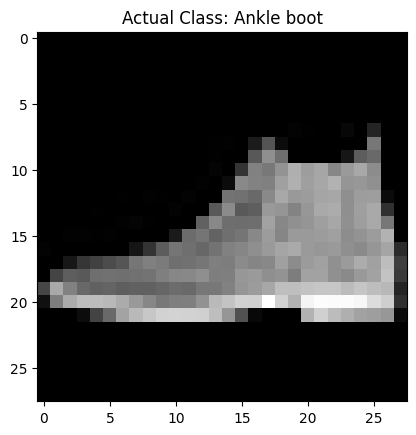

In [15]:
import numpy as np
import matplotlib.pyplot as plt 
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

predictions = model.predict(X_test[0].reshape(1,784))
print("Predicted Class: ",class_names[np.argmax(predictions)])

plt.imshow(X_test[0].reshape(28,28),cmap='gray')
plt.title("Actual Class: "+class_names[np.argmax(y_test[0])])

### Plotting Accuracy Metrics

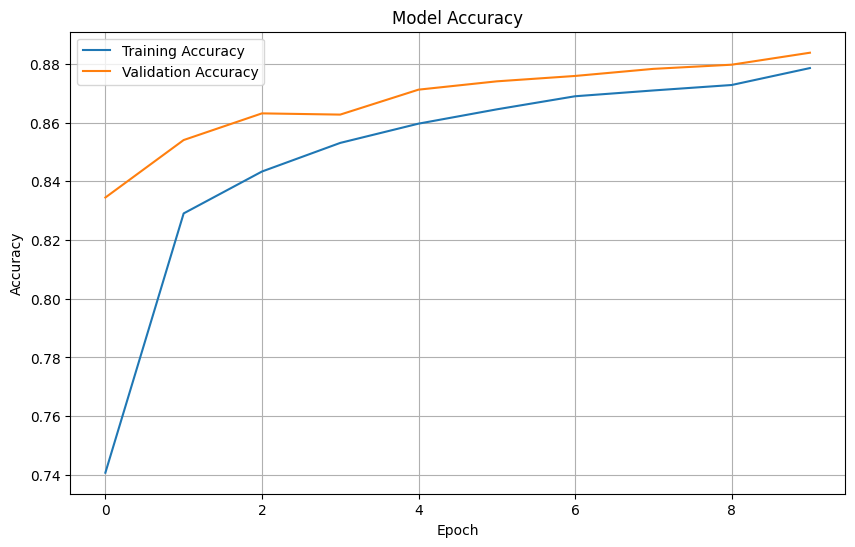

In [17]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()